In [1]:
import json
from torch.utils.data.distributed import DistributedSampler
from core.dataset import TrainDataset
from core.prefetch_dataloader import PrefetchDataLoader, CPUPrefetcher
from core.utils import get_blurred_masked_frames
import torch
import os
import numpy as np
import matplotlib.pyplot as plt

# propogation
from model.propainter import BidirectionalPropagation
from model.recurrent_flow_completion import RecurrentFlowCompleteNet



os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

config = json.load(open("./configs/train_depthcomp.json"))
config["world_size"] = torch.cuda.device_count()
# config["init_method"] = f"tcp://{get_master_ip()}:{args.port}"
config["distributed"] = True if config["world_size"] > 1 else False

if "local_rank" not in config:
    config["local_rank"] = config["global_rank"] = torch.cuda.device_count()
if torch.cuda.is_available():
    config["device"] = torch.device("cuda:{}".format(config["local_rank"]))
    print("Using ", torch.cuda.get_device_name(0))
else:
    config["device"] = "cpu"
    print("No GPU found, using CPU instead")


train_dataset = TrainDataset(config["train_data_loader"])
train_sampler = None
train_args = config["trainer"]
if config["distributed"]:
    train_sampler = DistributedSampler(
        train_dataset,
        num_replicas=config["world_size"],
        rank=config["global_rank"],
    )

dataloader_args = dict(
    dataset=train_dataset,
    batch_size=train_args["batch_size"] // config["world_size"],
    shuffle=(train_sampler is None),
    num_workers=train_args["num_workers"],
    sampler=train_sampler,
    drop_last=True,
)

train_loader = PrefetchDataLoader(
    train_args["num_prefetch_queue"], **dataloader_args
)
prefetcher = CPUPrefetcher(train_loader)





fix_flow_complete = RecurrentFlowCompleteNet(
    "./weights/recurrent_flow_completion.pth"
)
for p in fix_flow_complete.parameters():
    p.requires_grad = False
fix_flow_complete.to("cuda:0")
fix_flow_complete.eval();

Using  NVIDIA GeForce RTX 4090
Pretrained flow completion model has loaded...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

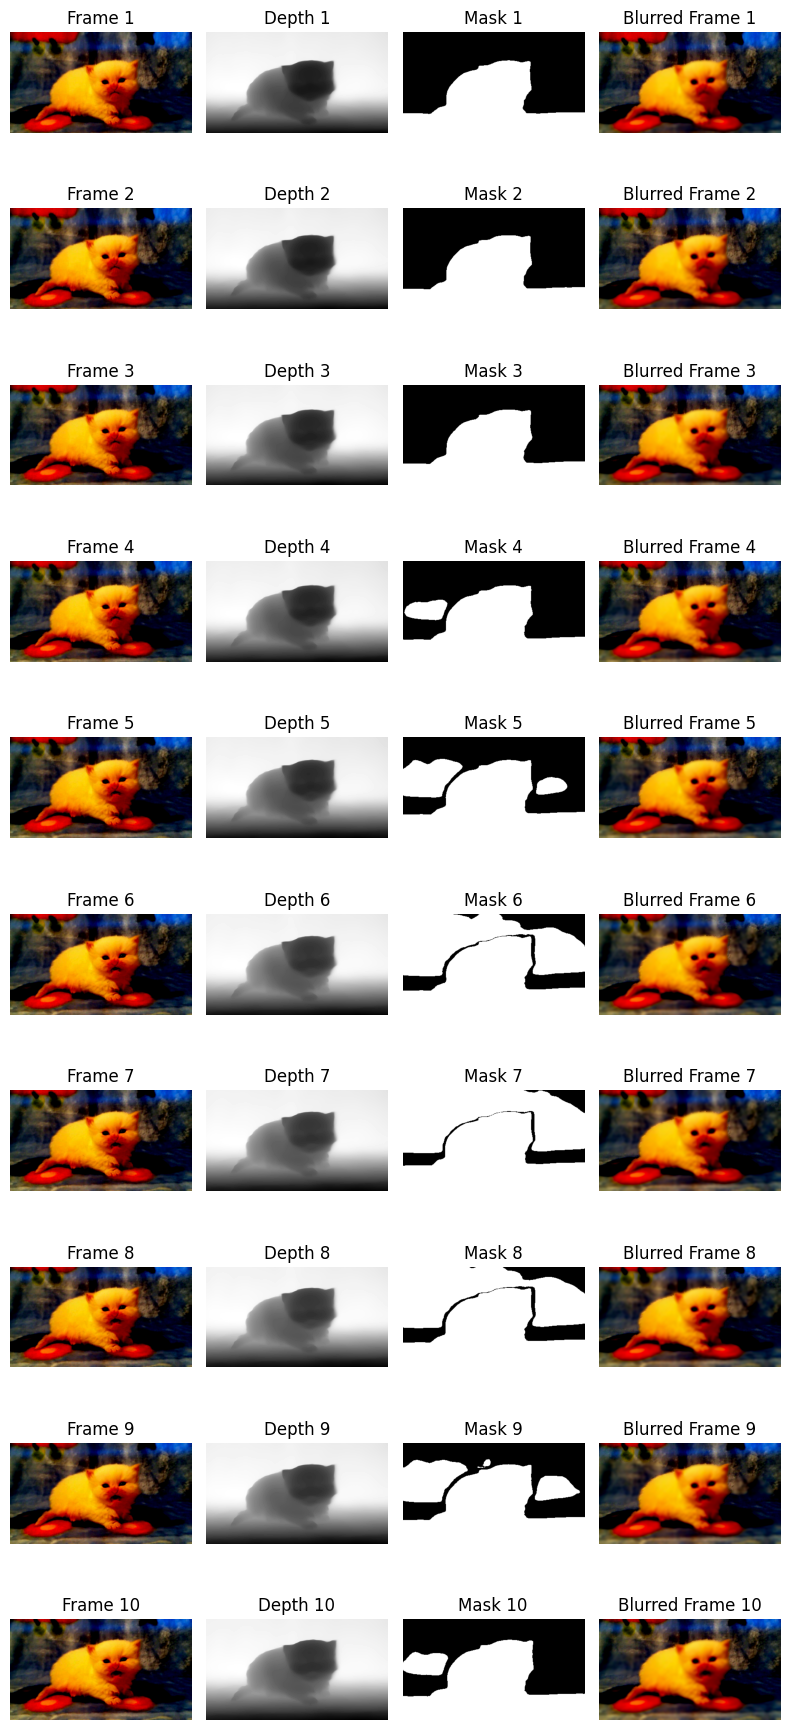

In [2]:
data = prefetcher.next();
frame_tensors, mask_tensors, depth_tensors, flows_f, flows_b, video_name = data

masked_frames = get_blurred_masked_frames(frame_tensors, mask_tensors)

img = 3


fig, axs = plt.subplots(10, 4, figsize=(8, 18))

for i in range(0,10):
    
    axs[i, 0].imshow(frame_tensors[img][i].permute(1, 2, 0).numpy())
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'Frame {i+1}')

    axs[i, 1].imshow(depth_tensors[img][i].squeeze().numpy(), cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'Depth {i+1}')

    axs[i, 2].imshow(mask_tensors[img][i].squeeze().numpy(), cmap='gray')
    axs[i, 2].axis('off')
    axs[i, 2].set_title(f'Mask {i+1}')

    axs[i, 3].imshow(masked_frames[img][i].cpu().numpy().transpose(1, 2, 0))
    axs[i, 3].axis('off')
    axs[i, 3].set_title(f'Blurred Frame {i+1}')

plt.tight_layout()
plt.show()


flow viz

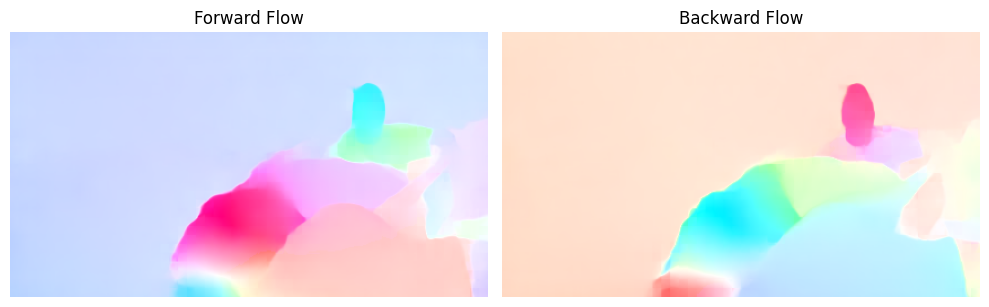

In [3]:
from torchvision.utils import flow_to_image
import matplotlib.pyplot as plt

flow_img_f = flow_to_image(flows_f[0][0].cpu().float())
flow_img_b = flow_to_image(flows_b[0][0].cpu().float())

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(flow_img_f.permute(1, 2, 0).numpy())
axs[0].set_title('Forward Flow')
axs[0].axis('off')

axs[1].imshow(flow_img_b.permute(1, 2, 0).numpy())
axs[1].set_title('Backward Flow')
axs[1].axis('off')

plt.tight_layout()
plt.show()



Propogation

In [4]:
device = "cuda:0"
l_t = 10


frames, depths, masks = (
    frame_tensors.to(device),
    depth_tensors.to(device).float(),
    mask_tensors.to(device).float(),
)
masked_frames = get_blurred_masked_frames(frames, masks)
masked_local_frames = masked_frames[:, :l_t, ...]


In [5]:
local_masks = masks[:, :l_t, ...].contiguous()
gt_flows_bi = (flows_f.to("cuda:0"), flows_b.to("cuda:0"))

pred_flows_bi, _ = fix_flow_complete.forward_bidirect_flow(
    gt_flows_bi, local_masks
)
pred_flows_bi = fix_flow_complete.combine_flow(
    gt_flows_bi, pred_flows_bi, local_masks
)

In [6]:
img_prop_module = BidirectionalPropagation(3, learnable=False)

_, _, prop_frames, updated_masks = img_prop_module(
    masked_local_frames,
    pred_flows_bi[0],
    pred_flows_bi[1],
    local_masks,
    interpolation="nearest"
)

c:\Users\wg19671\AppData\Local\anaconda3\envs\propainter\lib\site-packages\torch\functional.py:523: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

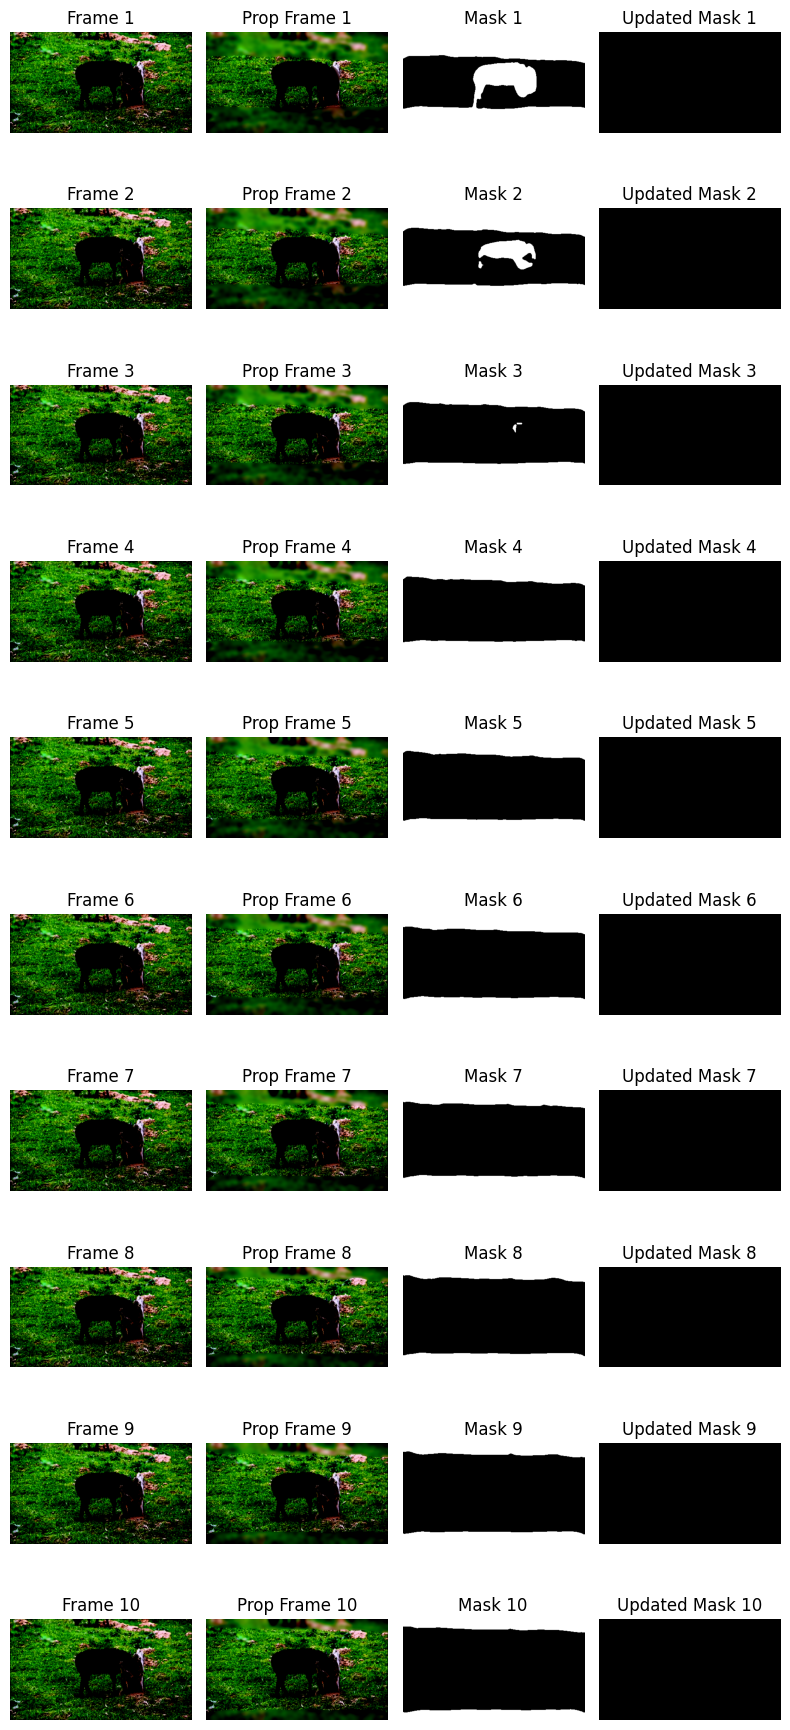

In [7]:

img = 1
fig, axs = plt.subplots(10, 4, figsize=(8, 18))

for i in range(0,10):
    
    axs[i, 0].imshow(frame_tensors[img][i].permute(1, 2, 0).numpy())
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'Frame {i+1}')

    axs[i, 1].imshow(prop_frames[img][i].cpu().permute(1, 2, 0).numpy(), cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'Prop Frame {i+1}')

    axs[i, 2].imshow(masks[img][i].cpu().squeeze().numpy(), cmap='gray')
    axs[i, 2].axis('off')
    axs[i, 2].set_title(f'Mask {i+1}')

    axs[i, 3].imshow(updated_masks[img][i].cpu().squeeze().numpy(), cmap='gray')
    axs[i, 3].axis('off')
    axs[i, 3].set_title(f'Updated Mask {i+1}')




plt.tight_layout()
plt.show()

In [8]:
# from model.modules.flow_comp_raft import RAFT_bi, FlowLoss, EdgeLoss
# from model.canny.canny_filter import Canny


# device = torch.device("cuda:0")
# train_dataset.fix_raft = RAFT_bi(device=device)
# train_dataset.canny = Canny(sigma=(2, 2), low_threshold=0.1, high_threshold=0.2)


# frames, masks, depths, flows_f, flows_b, _ = data
# frames, masks, depths = frames.to(device), masks.to(device), depths.to(device)
# masks, depths = masks.float(), depths.float()

# l_t = train_dataset.num_local_frames
# b, t, c, h, w = frames.size()
# gt_local_frames = frames[:, :l_t, ...]
# local_masks = masks[:, :l_t, ...].contiguous()
# local_depths = depths[:, :l_t, ...].contiguous()


# def get_edges(flows):
#     # (b, t, 2, H, W)
#     b, t, _, h, w = flows.shape
#     flows = flows.view(-1, 2, h, w)
#     flows_gray = (flows[:, 0, None] ** 2 + flows[:, 1, None] ** 2) ** 0.5
#     if flows_gray.max() < 1:
#         flows_gray = flows_gray * 0
#     else:
#         flows_gray = flows_gray / flows_gray.max()

#     magnitude, edges = train_dataset.canny(flows_gray.float())
#     edges = edges.view(b, t, 1, h, w)
#     return edges

# # get gt optical flow
# if flows_f[0] == "None" or flows_b[0] == "None":
#     gt_flows_bi = train_dataset.fix_raft(gt_local_frames)
# else:
#     gt_flows_bi = (flows_f.to(device), flows_b.to(device))

# # get gt edge
# gt_edges_forward = get_edges(gt_flows_bi[0])
# gt_edges_backward = get_edges(gt_flows_bi[1])
# gt_edges_bi = [gt_edges_forward, gt_edges_backward]

# # complete flow
# # 

In [9]:
import random

length = train_dataset.video_dict[train_dataset.video_names[0]]
sample_length = 10
num_ref_frame = train_dataset.num_ref_frames

complete_idx_set = list(range(length))
pivot = random.randint(0, length - sample_length)
local_idx = complete_idx_set[pivot : pivot + sample_length]
remain_idx = list(set(complete_idx_set) - set(local_idx))
ref_index = sorted(random.sample(remain_idx, num_ref_frame))

print("local_idx: ", local_idx)
print("remain_idx: ", remain_idx)
print("ref_index: ", ref_index)

local_idx:  [25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
remain_idx:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
ref_index:  [42, 92, 94]


In [10]:
from torchvision.models.optical_flow import Raft_Large_Weights
import torchvision.transforms.functional as F
from torchvision.models.optical_flow import raft_large
from PIL import Image
import os
import torch

weights = Raft_Large_Weights.DEFAULT
transforms = weights.transforms()

image_dir = "T:/ProPainter Datasets/davis/JPEGImages/surf"
image_files = os.listdir(image_dir)

images = []
for file in image_files:
    image_path = os.path.join(image_dir, file)
    image = F.pil_to_tensor(Image.open(image_path))
    images.append(image)

# Now you can use the loaded images as per your requirement


img1_batch = torch.stack([images[52], images[53]])
img2_batch = torch.stack([images[53], images[52]])


def preprocess(img1_batch, img2_batch):
    img1_batch = F.resize(img1_batch, size=[520, 960], antialias=False)
    img2_batch = F.resize(img2_batch, size=[520, 960], antialias=False)
    return transforms(img1_batch, img2_batch)


img1_batch, img2_batch = preprocess(img1_batch, img2_batch)



In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")



Using device: cuda


In [12]:
model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=True).to(device)
model = model.eval()

list_of_flows = model(img1_batch.to(device), img2_batch.to(device))

In [13]:
predicted_flows = list_of_flows[-1]
print(f"dtype = {predicted_flows.dtype}")
print(f"shape = {predicted_flows.shape} = (N, 2, H, W)")
print(f"min = {predicted_flows.min()}, max = {predicted_flows.max()}")

dtype = torch.float32
shape = torch.Size([2, 2, 520, 960]) = (N, 2, H, W)
min = -23.286624908447266, max = 23.891935348510742


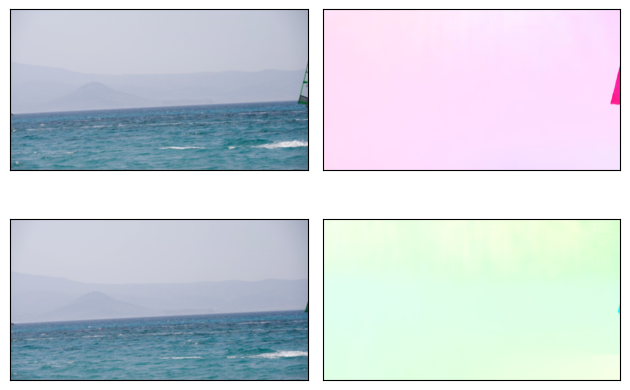

In [14]:
from torchvision.utils import flow_to_image
import matplotlib.pyplot as plt
import numpy as np


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

flow_imgs = flow_to_image(predicted_flows)

# The images have been mapped into [-1, 1] but for plotting we want them in [0, 1]
img1_batch = [(img1 + 1) / 2 for img1 in img1_batch]

grid = [[img1, flow_img] for (img1, flow_img) in zip(img1_batch, flow_imgs)]
plot(grid)

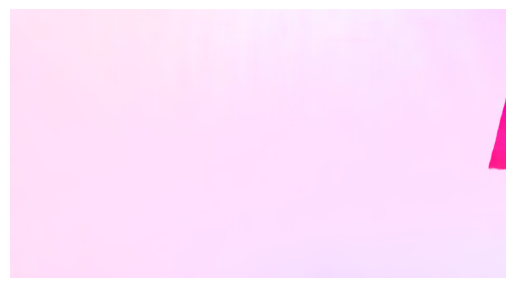

In [15]:
plt.tight_layout()
plt.axis("off")
plt.imshow(flow_imgs[0].permute(1, 2, 0).cpu().numpy())
plt.show()